In [ ]:
#| label: setup
#| echo: false

# Install required packages
!pip install -q dbfread pandas

# Import libraries
import os
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path
from dbfread import DBF
import glob
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

print("Setup complete.")


Mounted at /content/drive
Setup complete.


In [ ]:
#| label: extract-and-explore-datasets-fixed
#| echo: false

import pandas as pd
import zipfile
import os
import glob
from dbfread import DBF

# ============================================
# CONFIGURATION
# ============================================
sj_housing_zip = '/content/drive/MyDrive/San_Jose_Housing/sj_housing_sites.zip'
tax_assessor_zip = '/content/drive/MyDrive/San_Jose_Housing/tax-assessor-unl_01k8sgbp1h5y10h2gcg594tgr6.zip'

extract_dir = '/content/housing_data'
tax_assessor_extract_dir = '/content/tax_assessor_data'

# ============================================
# STEP 1: EXTRACT AND LOAD SJ HOUSING DATA
# ============================================
print("=" * 70)
print("STEP 1: EXTRACTING SAN JOSE HOUSING DATA")
print("=" * 70)

# Extract shapefile ZIP
if not os.path.exists(sj_housing_zip):
    raise FileNotFoundError(f"ZIP not found: {sj_housing_zip}")

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(sj_housing_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

dbf_files = sorted(glob.glob(os.path.join(extract_dir, '*.dbf')))
print(f"Found {len(dbf_files)} DBF files")

# Read all DBF files
all_dfs = []
for dbf_file in dbf_files:
    try:
        table = DBF(dbf_file, encoding='latin1', ignore_missing_memofile=True)
        df = pd.DataFrame(iter(table))
        all_dfs.append(df)
        print(f"  ✓ Loaded: {os.path.basename(dbf_file)} ({len(df):,} records)")
    except Exception as e:
        print(f"  ✗ Warning: {os.path.basename(dbf_file)} - {e}")

if not all_dfs:
    raise Exception("No DBF files read successfully")

sj_housing_df = pd.concat(all_dfs, ignore_index=True)
print(f"\n✓ Combined: {len(sj_housing_df):,} records | {sj_housing_df['Parcel ID'].nunique():,} unique parcels")

# ============================================
# STEP 2: EXTRACT AND LOAD TAX ASSESSOR DATA
# ============================================
print("\n" + "=" * 70)
print("STEP 2: EXTRACTING TAX ASSESSOR DATA")
print("=" * 70)

os.makedirs(tax_assessor_extract_dir, exist_ok=True)

with zipfile.ZipFile(tax_assessor_zip, 'r') as zip_ref:
    zip_ref.extractall(tax_assessor_extract_dir)
    print(f"✓ Extracted tax assessor files")

# Load ALL tax assessor CSV.gz files
csv_gz_files = sorted(glob.glob(os.path.join(tax_assessor_extract_dir, '*.csv.gz')))
csv_files = sorted(glob.glob(os.path.join(tax_assessor_extract_dir, '*.csv')))

print(f"\nFound {len(csv_gz_files)} compressed CSV files")
print(f"Found {len(csv_files)} uncompressed CSV files")

# Read and concatenate ALL tax assessor files
tax_dfs = []

if csv_gz_files:
    print("\nLoading compressed CSV files...")
    for csv_gz in csv_gz_files:
        try:
            df = pd.read_csv(csv_gz, compression='gzip')
            tax_dfs.append(df)
            print(f"  ✓ Loaded: {os.path.basename(csv_gz)} ({len(df):,} records)")
        except Exception as e:
            print(f"  ✗ Warning: {os.path.basename(csv_gz)} - {e}")

if csv_files:
    print("\nLoading uncompressed CSV files...")
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            tax_dfs.append(df)
            print(f"  ✓ Loaded: {os.path.basename(csv_file)} ({len(df):,} records)")
        except Exception as e:
            print(f"  ✗ Warning: {os.path.basename(csv_file)} - {e}")

if not tax_dfs:
    raise FileNotFoundError("No tax assessor CSV files loaded successfully")

# Concatenate all tax assessor data
tax_df = pd.concat(tax_dfs, ignore_index=True)
print(f"\n✓ Combined Tax Assessor Data: {len(tax_df):,} total records")

# ============================================
# STEP 3: EXPLORE SAN JOSE HOUSING DATA
# ============================================
print("\n" + "=" * 70)
print("STEP 3: SAN JOSE HOUSING DATA EXPLORATION")
print("=" * 70)

print(f"\nShape: {sj_housing_df.shape}")
print(f"Columns ({len(sj_housing_df.columns)}): {list(sj_housing_df.columns)}")

print("\n--- Column Data Types ---")
print(sj_housing_df.dtypes)

print("\n--- First 5 Records ---")
print(sj_housing_df.head())

print("\n--- Sample APN (Parcel ID) Values ---")
print(sj_housing_df['Parcel ID'].head(10).tolist())

print("\n--- Sample Address Values ---")
print(sj_housing_df['Address'].head(10).tolist())

print("\n--- Missing Data Summary ---")
missing = sj_housing_df.isnull().sum()
print(missing[missing > 0])

# ============================================
# STEP 4: EXPLORE TAX ASSESSOR DATA
# ============================================
print("\n" + "=" * 70)
print("STEP 4: TAX ASSESSOR DATA EXPLORATION")
print("=" * 70)

print(f"\nShape: {tax_df.shape}")
print(f"Columns ({len(tax_df.columns)}): {list(tax_df.columns)}")

print("\n--- Column Data Types ---")
print(tax_df.dtypes)

print("\n--- First 5 Records ---")
print(tax_df.head())

# Check for key columns
key_columns = ['PARCELNUMBERRAW', 'PROPERTYADDRESSFULL', 'DEEDLASTSALEDATE', 'DEEDLASTSALEPRICE']
print("\n--- Key Columns Check ---")
for col in key_columns:
    if col in tax_df.columns:
        print(f"✓ {col} exists")
    else:
        print(f"✗ {col} NOT FOUND")

print("\n--- Sample Parcel Number Values ---")
if 'PARCELNUMBERRAW' in tax_df.columns:
    print(tax_df['PARCELNUMBERRAW'].head(10).tolist())

print("\n--- Sample Address Values ---")
if 'PROPERTYADDRESSFULL' in tax_df.columns:
    print(tax_df['PROPERTYADDRESSFULL'].head(10).tolist())

print("\n--- Missing Data Summary (Key Columns) ---")
if all(col in tax_df.columns for col in key_columns):
    missing_tax = tax_df[key_columns].isnull().sum()
    print(missing_tax)

# ============================================
# STEP 5: COMPARISON SUMMARY
# ============================================
print("\n" + "=" * 70)
print("STEP 5: DATASET COMPARISON")
print("=" * 70)

print(f"\nSan Jose Housing:")
print(f"  - Total Files: {len(all_dfs)}")
print(f"  - Total Records: {len(sj_housing_df):,}")
print(f"  - Unique Parcels: {sj_housing_df['Parcel ID'].nunique():,}")
print(f"  - APN Column: 'Parcel ID'")
print(f"  - Address Column: 'Address'")

print(f"\nTax Assessor:")
print(f"  - Total Files: {len(tax_dfs)}")
print(f"  - Total Records: {len(tax_df):,}")
if 'PARCELNUMBERRAW' in tax_df.columns:
    print(f"  - Unique Parcels: {tax_df['PARCELNUMBERRAW'].nunique():,}")
    print(f"  - APN Column: 'PARCELNUMBERRAW'")
if 'PROPERTYADDRESSFULL' in tax_df.columns:
    print(f"  - Address Column: 'PROPERTYADDRESSFULL'")

print("\n" + "=" * 70)
print("READY FOR MATCHING")
print("=" * 70)
print("\nNext steps:")
print("1. Review the column names and data formats above")
print("2. Verify APN and address formats match between datasets")
print("3. Proceed with APN + address matching logic")


STEP 1: EXTRACTING SAN JOSE HOUSING DATA
Found 10 DBF files
  ✓ Loaded: structures_yr0_to_1950.dbf (24,166 records)
  ✓ Loaded: structures_yr1951_to_1958.dbf (20,881 records)
  ✓ Loaded: structures_yr1959_to_1961.dbf (21,440 records)
  ✓ Loaded: structures_yr1962_to_1966.dbf (23,065 records)
  ✓ Loaded: structures_yr1967_to_1970.dbf (24,585 records)
  ✓ Loaded: structures_yr1971_to_1974.dbf (23,860 records)
  ✓ Loaded: structures_yr1975_to_1979.dbf (24,566 records)
  ✓ Loaded: structures_yr1980_to_1987.dbf (22,546 records)
  ✓ Loaded: structures_yr1988_to_2002.dbf (24,700 records)
  ✓ Loaded: structures_yr2003_to_2025.dbf (20,432 records)

✓ Combined: 230,241 records | 227,525 unique parcels

STEP 2: EXTRACTING TAX ASSESSOR DATA
✓ Extracted tax assessor files

Found 32 compressed CSV files
Found 0 uncompressed CSV files

Loading compressed CSV files...
  ✓ Loaded: tax-assessor_0_0_0.csv.gz (7,136 records)
  ✓ Loaded: tax-assessor_0_1_0.csv.gz (6,681 records)
  ✓ Loaded: tax-assessor_0_

### MATCHING

In [ ]:
!pip install rapidfuzz

import re
import numpy as np
from rapidfuzz import fuzz, process
from math import radians, cos, sin, asin, sqrt
import pandas as pd

# UTILITY FUNCTIONS

def normalize_address(addr):
    """Improved address normalization with better standardization"""
    if pd.isna(addr) or addr == '':
        return ''
    addr_str = str(addr).strip().upper()

    # Remove zip codes
    addr_str = re.sub(r'\b\d{5}(-\d{4})?\b', '', addr_str)
    # Remove state
    addr_str = re.sub(r'\b(CA|CALIFORNIA)\b', '', addr_str, flags=re.IGNORECASE)
    # Remove city
    addr_str = re.sub(r'\bSAN\s+JOSE\b', '', addr_str, flags=re.IGNORECASE)
    # Remove unit/apt/# designations
    addr_str = re.sub(r'\s+UNIT\s+\S+', '', addr_str, flags=re.IGNORECASE)
    addr_str = re.sub(r'\s+APT\s+\S+', '', addr_str, flags=re.IGNORECASE)
    addr_str = re.sub(r'\s+#\s*\S+', '', addr_str)
    # Remove fractional addresses like "1/2"
    addr_str = re.sub(r'\s+\d+/\d+', '', addr_str)
    # Remove trailing single letters (like unit letters)
    addr_str = re.sub(r'\s+[A-Z]$', '', addr_str)

    # IMPROVED: Normalize direction abbreviations
    addr_str = re.sub(r'\bN\b', 'NORTH', addr_str)
    addr_str = re.sub(r'\bS\b', 'SOUTH', addr_str)
    addr_str = re.sub(r'\bE\b', 'EAST', addr_str)
    addr_str = re.sub(r'\bW\b', 'WEST', addr_str)
    addr_str = re.sub(r'\bNE\b', 'NORTHEAST', addr_str)
    addr_str = re.sub(r'\bNW\b', 'NORTHWEST', addr_str)
    addr_str = re.sub(r'\bSE\b', 'SOUTHEAST', addr_str)
    addr_str = re.sub(r'\bSW\b', 'SOUTHWEST', addr_str)

    # IMPROVED: Normalize street types
    addr_str = re.sub(r'\bST\b', 'STREET', addr_str)
    addr_str = re.sub(r'\bRD\b', 'ROAD', addr_str)
    addr_str = re.sub(r'\bAVE\b', 'AVENUE', addr_str)
    addr_str = re.sub(r'\bBLVD\b', 'BOULEVARD', addr_str)
    addr_str = re.sub(r'\bDR\b', 'DRIVE', addr_str)
    addr_str = re.sub(r'\bLN\b', 'LANE', addr_str)
    addr_str = re.sub(r'\bCT\b', 'COURT', addr_str)
    addr_str = re.sub(r'\bPL\b', 'PLACE', addr_str)
    addr_str = re.sub(r'\bPKWY\b', 'PARKWAY', addr_str)
    addr_str = re.sub(r'\bCIR\b', 'CIRCLE', addr_str)
    addr_str = re.sub(r'\bTER\b', 'TERRACE', addr_str)
    addr_str = re.sub(r'\bWY\b', 'WAY', addr_str)

    # Clean up commas and extra spaces
    addr_str = re.sub(r'\s*,\s*', ' ', addr_str)
    addr_str = re.sub(r'\s+', ' ', addr_str).strip()
    return addr_str

def haversine_distance(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371000
    return c * r

# COLUMN RENAME MAP
column_mapping = {
    'Parcel ID': 'Parcel ID',
    'Address': 'Address',
    'Property': 'Property Type',
    'Current U': 'Current Use',
    'Total Ass': 'Total Assessed Value',
    'Assessed': 'Assessed Land Value',
    'Assesse1': 'Assessed Improvement Value',
    'Land Size': 'Land Size Acres',
    'Year Built': 'Year Built',
    'Number of': 'Number of Buildings',
    'Building': 'Building Stories',
    'Units': 'Number of Units',
    'Buildin1': 'Building SqFt',
    'Affordabl': 'affordable_rental_flag',
    'Affordab1': 'affordable_rental_mf_flag',
    'Affordab2': 'affordable_rental_sf_flag',
    'Affordab3': 'affordable_rental_sro_flag',
    'Federally': 'federal_rental_units',
    'Federall1': 'federal_rental_s202_units',
    'Federall2': 'federal_rental_s8_units',
    'Federall3': 'federal_rental_lihtc_units',
    'Federall4': 'federal_rental_fha_units',
    'Federall5': 'federal_rental_home_units',
    'Mobile Ho': 'mobile_home_flag',
    'Affordab4': 'Affordable Housing Units',
    'Affordab5': 'Affordable Housing Units MF',
    'Affordab6': 'Affordable Housing Units SF',
    'Affordab7': 'Affordable Housing Units SRO',
    'Owners': 'Owners'
}

# Tax assessor: REMOVED Pool Area, KEPT escalator_flag and poolhouse_flag
assessor_map = {
    'PARCELNUMBERRAW': 'Parcel ID Tax',
    'PROPERTYADDRESSFULL': 'Address Tax',
    'LATITUDE': 'Latitude',
    'LONGITUDE': 'Longitude',
    'DEEDLASTSALEDATE': 'Last Sale Date',
    'DEEDLASTSALEPRICE': 'Last Sale Price',
    'PROPERTYUSEGROUP': 'Property Use Group',
    'BEDROOMSCOUNT': 'Bedrooms',
    'BATHCOUNT': 'Bathrooms',
    'AREALOTSF': 'Lot Area SqFt',
    'AREALOTACRES': 'Lot Area Acres',
    'ESCALATORFLAG': 'escalator_flag',
    'POOLHOUSEFLAG': 'poolhouse_flag',
    'PARKINGGARAGEAREA': 'Parking Garage Area'
}

# Apply col renaming to SJ and Tax Assessor
sj_clean = sj_housing_df.rename(columns=column_mapping)
tax_clean = tax_df[[k for k in assessor_map if k in tax_df.columns]].rename(columns=assessor_map)

# IDs and address normalization
sj_clean['parcel_clean'] = sj_clean['Parcel ID'].astype(str).str.replace('-', '').str.replace(' ', '').str.strip().str.upper()
tax_clean['parcel_clean'] = tax_clean['Parcel ID Tax'].astype(str).str.replace('-', '').str.replace(' ', '').str.strip().str.upper()
sj_clean['address_norm'] = sj_clean['Address'].apply(normalize_address)
tax_clean['address_norm'] = tax_clean['Address Tax'].apply(normalize_address)

# Initialize match tracking
match_counts = {
    'parcel_match': 0,
    'address_match': 0,
    'fuzzy_match': 0,
    'no_match': 0
}

# Add match type column to track how each record was matched
sj_clean['match_type'] = 'no_match'

# MATCH ON APN
print("="*80)
print("MATCHING PROCESS")
print("="*80)
merged = sj_clean.merge(tax_clean.drop(columns=['Parcel ID Tax', 'Address Tax', 'address_norm'], errors='ignore'),
                       on='parcel_clean', how='left', suffixes=('', '_tax'), indicator=True)

# Track parcel matches
parcel_matched = merged['_merge'] == 'both'
merged.loc[parcel_matched, 'match_type'] = 'parcel_match'
match_counts['parcel_match'] = parcel_matched.sum()
print(f"✓ Parcel ID matches: {match_counts['parcel_match']:,}")

# Drop the indicator column
merged = merged.drop(columns=['_merge'])

# MATCH ON ADDRESS
if merged['Last Sale Date'].isna().sum() > 0:
    unmatched = merged[merged['Last Sale Date'].isna()].copy()
    addr_lookup = tax_clean[tax_clean['address_norm'] != ''].drop_duplicates('address_norm', keep='first')
    update_cols = [col for col in tax_clean.columns if col not in ['parcel_clean', 'Parcel ID Tax', 'Address Tax', 'address_norm']]
    addr_match = unmatched[['address_norm']].merge(addr_lookup[['address_norm'] + update_cols],
                                                   on='address_norm', how='left', indicator=True)

    # Track address matches
    addr_matched_mask = addr_match['_merge'] == 'both'
    for col in update_cols:
        mask = addr_match[col].notna()
        merged.loc[mask.index[mask], col] = addr_match.loc[mask, col].values

    # Update match type for address matches
    addr_matched_indices = addr_match[addr_matched_mask].index
    merged.loc[addr_matched_indices, 'match_type'] = 'address_match'
    match_counts['address_match'] = addr_matched_mask.sum()
    print(f"✓ Normalized address matches: {match_counts['address_match']:,}")

# FUZZY ADDRESS LOGIC (stricter)
still_unmatched = merged[merged['Last Sale Date'].isna()]
fuzzy_matched_count = 0

if 0 < len(still_unmatched) <= 3000:
    tax_dedup = tax_clean[tax_clean['address_norm'] != ''].drop_duplicates('address_norm')
    update_cols = [col for col in tax_clean.columns if col not in ['parcel_clean', 'Parcel ID Tax', 'Address Tax', 'address_norm']]
    tax_dict = tax_dedup.set_index('address_norm')[update_cols].to_dict('index')

    import tqdm
    for idx, row in tqdm.tqdm(still_unmatched.iterrows(), total=len(still_unmatched), desc="Fuzzy matching"):
        if pd.notna(row['address_norm']) and row['address_norm'] != '':
            result = process.extractOne(row['address_norm'], list(tax_dict.keys()), scorer=fuzz.ratio, score_cutoff=94)
            if result:
                best_match, score, _ = result
                for col in update_cols:
                    merged.loc[idx, col] = tax_dict[best_match][col]
                merged.loc[idx, 'match_type'] = 'fuzzy_match'
                fuzzy_matched_count += 1

    match_counts['fuzzy_match'] = fuzzy_matched_count
    print(f"✓ Fuzzy address matches: {match_counts['fuzzy_match']:,}")

# Count remaining unmatched
match_counts['no_match'] = (merged['match_type'] == 'no_match').sum()
print(f"✗ No match found: {match_counts['no_match']:,}")

print(f"\nTotal records: {len(merged):,}")
print(f"Match rate: {((len(merged) - match_counts['no_match']) / len(merged) * 100):.2f}%")

# DROP REPEATED COLUMNS AND REMOVE tax assessed values (by name)
merged = merged.loc[:, ~merged.columns.str.lower().str.contains('tax_assessed_value')]

# Remove address_norm, parcel_clean, and duplicates
merged = merged.loc[:, ~merged.columns.duplicated()]
merged = merged.T.drop_duplicates().T
if 'parcel_clean' in merged.columns:
    merged = merged.drop(columns=['parcel_clean'])
if 'address_norm' in merged.columns:
    merged = merged.drop(columns=['address_norm'])

# HUMAN-READABLE COLUMN ORDER (removed Pool Area, kept escalator_flag)
col_order = [
    'Parcel ID', 'Address', 'Latitude', 'Longitude',
    'Property Type', 'Current Use', 'Property Use Group',
    'Total Assessed Value', 'Assessed Land Value', 'Assessed Improvement Value',
    'Last Sale Price', 'Last Sale Date',
    'sale_year',
    'Land Size Acres', 'Lot Area SqFt', 'Lot Area Acres',
    'Year Built', 'Number of Buildings', 'Building Stories', 'Number of Units', 'Building SqFt',
    'Bedrooms', 'Bathrooms',
    'escalator_flag', 'poolhouse_flag', 'Parking Garage Area',
    'affordable_rental_flag', 'affordable_rental_mf_flag', 'affordable_rental_sf_flag', 'affordable_rental_sro_flag',
    'Affordable Housing Units', 'Affordable Housing Units MF', 'Affordable Housing Units SF', 'Affordable Housing Units SRO',
    'federal_rental_units', 'federal_rental_s202_units', 'federal_rental_s8_units', 'federal_rental_lihtc_units', 'federal_rental_fha_units', 'federal_rental_home_units',
    'mobile_home_flag', 'Owners', 'match_type'
]

col_order_final = [col for col in col_order if col in merged.columns]
remaining_cols = [col for col in merged.columns if col not in col_order_final]
merged = merged[col_order_final + remaining_cols]

# Harmonize/compute sale_year (for plotting etc):
merged['sale_year'] = pd.to_datetime(merged['Last Sale Date'], errors='coerce').dt.year

# ===== ANALYSIS SECTION =====
print("\n" + "="*80)
print("PROPERTY TYPE DISTRIBUTION")
print("="*80)
if 'Property Type' in merged.columns:
    prop_type_dist = merged['Property Type'].value_counts()
    print(prop_type_dist)
    print(f"\nTotal records: {len(merged)}")
    print(f"Structure count: {prop_type_dist.get('Structure', 0)}")

print("\n" + "="*80)
print("ZERO VALUE SALES ANALYSIS")
print("="*80)
if 'Last Sale Price' in merged.columns:
    # Convert to numeric
    merged['Last Sale Price'] = pd.to_numeric(merged['Last Sale Price'], errors='coerce')

    zero_sales = merged[merged['Last Sale Price'] == 0]
    print(f"Total records with sales data: {merged['Last Sale Price'].notna().sum()}")
    print(f"Records with $0 sale price: {len(zero_sales)}")
    if merged['Last Sale Price'].notna().sum() > 0:
        print(f"Percentage of zero-value sales: {len(zero_sales) / merged['Last Sale Price'].notna().sum() * 100:.2f}%")

    # REMOVE ZERO VALUE SALES: Set sale price and year to NaN for $0 sales
    print(f"\n✓ Removing sale price and year data for {len(zero_sales):,} zero-value sales...")
    merged.loc[merged['Last Sale Price'] == 0, 'Last Sale Price'] = np.nan
    merged.loc[merged['Last Sale Price'].isna(), 'Last Sale Date'] = np.nan
    merged.loc[merged['Last Sale Price'].isna(), 'sale_year'] = np.nan

    print(f"After cleanup - Records with valid sales data: {merged['Last Sale Price'].notna().sum()}")

print("\n" + "="*80)

# EXPORT CSV
csv_path = '/content/drive/MyDrive/San_Jose_Housing/san_jose_housing_matched_sales.csv'
merged.to_csv(csv_path, index=False)
print(f"\n✓ Saved CSV: {csv_path}")
print(f"  - {len(merged):,} records")
print(f"  - {len(merged.columns)} columns")
print(f"  - {merged['Last Sale Price'].notna().sum():,} records with valid sale data")

merged.head(5)

MATCHING PROCESS
✓ Parcel ID matches: 227,810
✓ Normalized address matches: 33,005
✗ No match found: 1,992

Total records: 230,241
Match rate: 99.13%

PROPERTY TYPE DISTRIBUTION
Property Type
Structure    230241
Name: count, dtype: int64

Total records: 230241
Structure count: 230241

ZERO VALUE SALES ANALYSIS
Total records with sales data: 193828
Records with $0 sale price: 28549
Percentage of zero-value sales: 14.73%

✓ Removing sale price and year data for 28,549 zero-value sales...
After cleanup - Records with valid sales data: 165279


✓ Saved CSV: /content/drive/MyDrive/San_Jose_Housing/san_jose_housing_matched_sales.csv
  - 230,241 records
  - 47 columns
  - 165,279 records with valid sale data


,Parcel ID,Address,Latitude,Longitude,Property Type,Current Use,Property Use Group,Total Assessed Value,Assessed Land Value,Assessed Improvement Value,...,mobile_home_flag,Owners,match_type,Federall11,Rent Stab,Rent Sta1,Rent Sta2,Rent Sta3,Rent Sta4,sale_year
0,249-44-035,"400 N 2nd St 1/2, San Jose, CA, 95112",37.343599,-121.895621,Structure,Two Family,COMMERCIAL,785770.0,211812.0,573958.0,...,null,-,address_match,,null,null,null,null,null,2005.0
1,249-44-036,"402 N 2nd St, San Jose, CA, 95112",37.341084,-121.893341,Structure,Two Family,Commercial,769159.0,348524.0,420635.0,...,null,-,address_match,,null,null,null,null,null,2013.0
2,249-44-037,"404 N 2nd St Unit 1, San Jose, CA, 95112",37.341452,-121.893494,Structure,Three and Four Family,COMMERCIAL,1004826.0,308143.0,696683.0,...,null,-,address_match,,4.0,null,null,4.0,null,2005.0
3,249-44-038,"412 N 2nd St, San Jose, CA, 95112",37.344222,-121.894131,Structure,Single Family,Residential,1196607.0,358981.0,837626.0,...,null,-,address_match,,null,null,null,null,null,2021.0
4,249-44-039,"428 N 2nd St A, San Jose, CA, A",37.343765,-121.894343,Structure,Two Family,Residential,1114268.0,265302.0,848966.0,...,null,-,parcel_match,,null,null,null,null,null,2025.0


### Sales coverage across years

ANALYZING SALE PRICE COVERAGE BY YEAR

✓ Loaded 230,241 records

CLEANING SALE DATA

Records with sale price: 165,279
Records with valid sale price: 164,915
Records with valid year (1950-2025): 164,915

COVERAGE BY YEAR

Years covered: 1988 - 2025
Total years: 38

Recent years (2000+): 26 years
Avg sales per year (2000+): 5152

Years with 1,000+ sales: 38
First year with 1,000+ sales: 1988

--- Years with Highest Sales Volume ---
    sale_year  count  median_price
33       2021   9271     1230000.0
34       2022   6554     1350000.0
32       2020   6280     1075000.0
21       2009   6166      415000.0
29       2017   6028      900000.0
24       2012   5990      495000.0
36       2024   5839     1450000.0
31       2019   5682     1015000.0
27       2015   5661      767000.0
25       2013   5646      641000.0

--- Recent Years (2020-2025) ---
    sale_year  count  median_price
32       2020   6280     1075000.0
33       2021   9271     1230000.0
34       2022   6554     1350000.0
35     

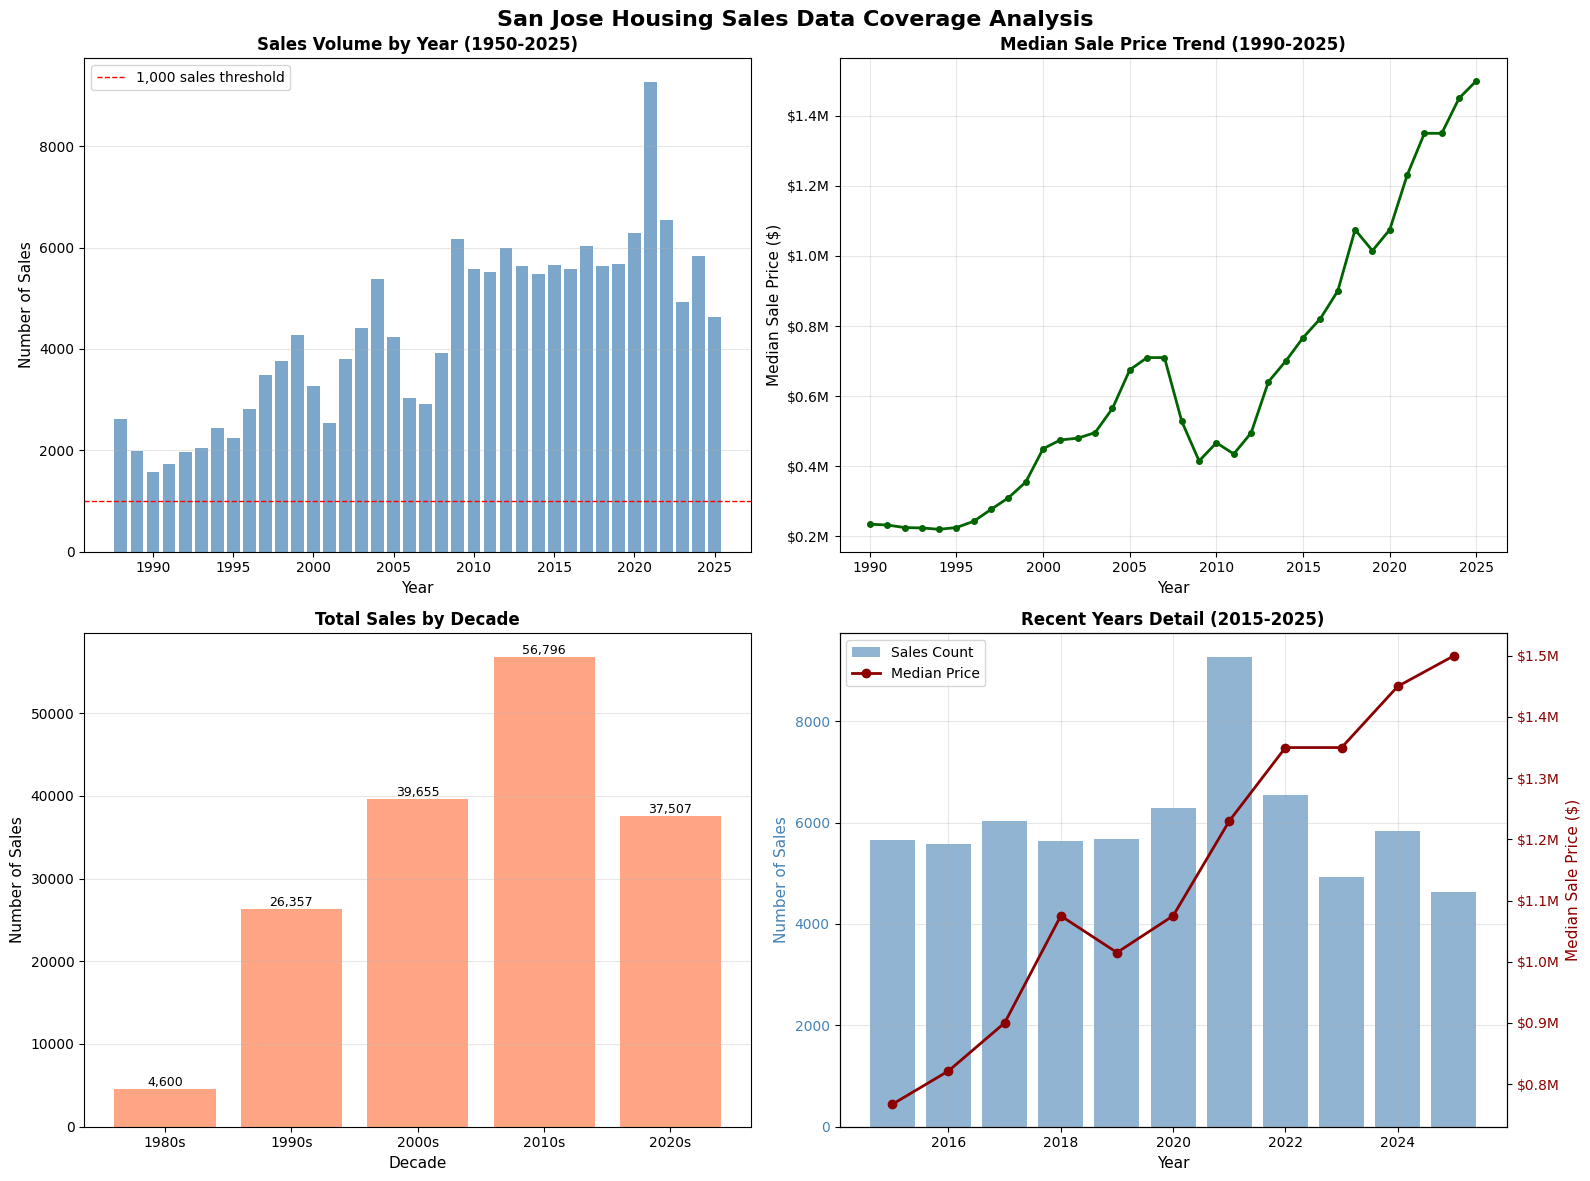

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# LOAD DATA
# ============================================
print("=" * 70)
print("ANALYZING SALE PRICE COVERAGE BY YEAR")
print("=" * 70)

csv_path = '/content/drive/MyDrive/San_Jose_Housing/san_jose_housing_matched_sales.csv'
df = pd.read_csv(csv_path)

print(f"\n✓ Loaded {len(df):,} records")

# ============================================
# DATA CLEANING
# ============================================
print("\n" + "=" * 70)
print("CLEANING SALE DATA")
print("=" * 70)

sales_col = 'Last Sale Price'
date_col = 'Last Sale Date'

# Filter for valid sale prices (remove negatives and extreme outliers)
df_sales = df[df[sales_col].notna()].copy()
print(f"\nRecords with sale price: {len(df_sales):,}")

df_sales = df_sales[
    (df_sales[sales_col] > 0) &
    (df_sales[sales_col] < 50_000_000)
]
print(f"Records with valid sale price: {len(df_sales):,}")

# Parse sale year
df_sales['sale_year'] = pd.to_datetime(df_sales[date_col], errors='coerce').dt.year

df_sales = df_sales[
    (df_sales['sale_year'] >= 1950) &
    (df_sales['sale_year'] <= 2025)
]
print(f"Records with valid year (1950-2025): {len(df_sales):,}")

# ============================================
# YEARLY ANALYSIS
# ============================================
print("\n" + "=" * 70)
print("COVERAGE BY YEAR")
print("=" * 70)

yearly_stats = df_sales.groupby('sale_year').agg({
    sales_col: ['count', 'mean', 'median', 'std', 'min', 'max']
}).round(0)
yearly_stats.columns = ['count', 'mean_price', 'median_price', 'std_price', 'min_price', 'max_price']
yearly_stats = yearly_stats.reset_index()

print(f"\nYears covered: {yearly_stats['sale_year'].min():.0f} - {yearly_stats['sale_year'].max():.0f}")
print(f"Total years: {len(yearly_stats)}")

# Recent years
recent_stats = yearly_stats[yearly_stats['sale_year'] >= 2000].copy()
print(f"\nRecent years (2000+): {len(recent_stats)} years")
print(f"Avg sales per year (2000+): {recent_stats['count'].mean():.0f}")

good_coverage = yearly_stats[yearly_stats['count'] >= 1000].copy()
print(f"\nYears with 1,000+ sales: {len(good_coverage)}")
print(f"First year with 1,000+ sales: {good_coverage['sale_year'].min():.0f}")

print("\n--- Years with Highest Sales Volume ---")
print(yearly_stats.nlargest(10, 'count')[['sale_year', 'count', 'median_price']])

print("\n--- Recent Years (2020-2025) ---")
recent = yearly_stats[yearly_stats['sale_year'] >= 2020]
print(recent[['sale_year', 'count', 'median_price']])

# ============================================
# DECADE ANALYSIS
# ============================================
print("\n" + "=" * 70)
print("COVERAGE BY DECADE")
print("=" * 70)

df_sales['decade'] = (df_sales['sale_year'] // 10) * 10

decade_stats = df_sales.groupby('decade').agg({
    sales_col: ['count', 'mean', 'median']
}).round(0)
decade_stats.columns = ['count', 'mean_price', 'median_price']
decade_stats = decade_stats.reset_index()
decade_stats['decade_label'] = decade_stats['decade'].astype(int).astype(str) + 's'
print("\n--- Sales by Decade ---")
print(decade_stats)

# ============================================
# DATA QUALITY ASSESSMENT
# ============================================
print("\n" + "=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

total_properties = len(df)
properties_with_sales = len(df_sales)
coverage_rate = properties_with_sales / total_properties * 100

print(f"\n📊 Overall Coverage:")
print(f"  Total properties: {total_properties:,}")
print(f"  Properties with valid sales: {properties_with_sales:,}")
print(f"  Coverage rate: {coverage_rate:.2f}%")

print(f"\n📅 Coverage by Time Period:")
for period in [(1950, 1979), (1980, 1999), (2000, 2009), (2010, 2019), (2020, 2025)]:
    start, end = period
    period_data = yearly_stats[
        (yearly_stats['sale_year'] >= start) &
        (yearly_stats['sale_year'] <= end)
    ]
    total_sales = period_data['count'].sum()
    avg_per_year = period_data['count'].mean() if len(period_data) else 0
    print(f"  {start}-{end}: {total_sales:,} sales ({avg_per_year:.0f} avg/year)")

print(f"\n⚠️ Years with Low Coverage (<500 sales):")
low_coverage = yearly_stats[
    (yearly_stats['count'] < 500) &
    (yearly_stats['sale_year'] >= 1990)
]
if len(low_coverage) > 0:
    print(low_coverage[['sale_year', 'count']])
else:
    print("  None! Good coverage across all recent years.")

# ============================================
# CREATE VISUALIZATIONS
# ============================================
print("\n" + "=" * 70)
print("CREATING VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('San Jose Housing Sales Data Coverage Analysis', fontsize=16, fontweight='bold')

# Plot 1: Sales count by year
ax1 = axes[0, 0]
ax1.bar(yearly_stats['sale_year'], yearly_stats['count'], color='steelblue', alpha=0.7)
ax1.axhline(y=1000, color='red', linestyle='--', linewidth=1, label='1,000 sales threshold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Number of Sales', fontsize=11)
ax1.set_title('Sales Volume by Year (1950-2025)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# Plot 2: Median price by year
ax2 = axes[0, 1]
recent_yearly = yearly_stats[yearly_stats['sale_year'] >= 1990].copy()
ax2.plot(recent_yearly['sale_year'], recent_yearly['median_price'],
         marker='o', linewidth=2, markersize=4, color='darkgreen')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Median Sale Price ($)', fontsize=11)
ax2.set_title('Median Sale Price Trend (1990-2025)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Plot 3: Sales by decade
ax3 = axes[1, 0]
ax3.bar(decade_stats['decade_label'], decade_stats['count'], color='coral', alpha=0.7)
ax3.set_xlabel('Decade', fontsize=11)
ax3.set_ylabel('Number of Sales', fontsize=11)
ax3.set_title('Total Sales by Decade', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(zip(decade_stats['decade_label'], decade_stats['count'])):
    ax3.text(i, count, f'{int(count):,}', ha='center', va='bottom', fontsize=9)

# Plot 4: Recent years detail (2015-2025)
ax4 = axes[1, 1]
recent_detail = yearly_stats[yearly_stats['sale_year'] >= 2015].copy()
ax4_twin = ax4.twinx()

bars = ax4.bar(recent_detail['sale_year'], recent_detail['count'],
               color='steelblue', alpha=0.6, label='Sales Count')
line = ax4_twin.plot(recent_detail['sale_year'], recent_detail['median_price'],
                     marker='o', color='darkred', linewidth=2, markersize=6, label='Median Price')

ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Number of Sales', fontsize=11, color='steelblue')
ax4_twin.set_ylabel('Median Sale Price ($)', fontsize=11, color='darkred')
ax4.set_title('Recent Years Detail (2015-2025)', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='steelblue')
ax4_twin.tick_params(axis='y', labelcolor='darkred')
ax4_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax4.grid(alpha=0.3)

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/San_Jose_Housing/sales_coverage_analysis.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved visualization: sales_coverage_analysis.png")
plt.show()


#### Affordable v/s Non Affordable

##### Use extracted houses from the map for affordable housing in San Jose

In [ ]:
import pandas as pd
import numpy as np
import re
from math import radians, cos, sin, asin, sqrt

# ============================================
# LOAD DATASETS
# ============================================
print("=" * 80)
print("MATCHING AFFORDABLE HOUSING WITH SALES DATA (1:1 UNIQUE MATCHING)")
print("=" * 80)

# Load main matched sales data
sales_csv = '/content/drive/MyDrive/San_Jose_Housing/san_jose_housing_matched_sales.csv'
df_sales = pd.read_csv(sales_csv)
print(f"\n✓ Loaded sales data: {len(df_sales):,} records")

# Load extracted affordable housing from map
affordable_csv = '/content/drive/MyDrive/San_Jose_Housing/extracted_san_jose_affordable_housing_from_map.csv'
df_affordable = pd.read_csv(affordable_csv)
print(f"✓ Loaded affordable housing data: {len(df_affordable):,} developments")

# ============================================
# VECTORIZED HAVERSINE FUNCTION
# ============================================
def haversine_vectorized(lat1, lon1, lat2_array, lon2_array):
    """
    Vectorized haversine calculation for one point against an array of points.
    Much faster than loop-based calculation.
    Returns array of distances in meters.
    """
    # Convert to radians
    lat1, lon1 = radians(lat1), radians(lon1)
    lat2_array = np.radians(lat2_array)
    lon2_array = np.radians(lon2_array)

    # Haversine formula
    dlat = lat2_array - lat1
    dlon = lon2_array - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2_array) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Earth radius in meters
    r = 6371000
    return c * r

# ============================================
# PREPARE AFFORDABLE HOUSING DATA
# ============================================
print("\n" + "=" * 80)
print("PREPARING AFFORDABLE HOUSING DATA")
print("=" * 80)

# Calculate total units from TOTALAFFUNITS + HUDUNITS
df_affordable['total_units_from_map'] = df_affordable['TOTALAFFUNITS'].fillna(0) + df_affordable['HUDUNITS'].fillna(0)
print(f"\n✓ Calculated total units for {len(df_affordable)} affordable developments")
print(f"  Total affordable units: {df_affordable['total_units_from_map'].sum():,.0f}")

# Check geocoding availability
affordable_with_geo = df_affordable[
    df_affordable['LATITUDE'].notna() &
    df_affordable['LONGITUDE'].notna()
].copy()
sales_with_geo = df_sales[
    df_sales['Latitude'].notna() &
    df_sales['Longitude'].notna()
].copy()

print(f"\n✓ Geocoding availability:")
print(f"  Affordable developments with lat/lon: {len(affordable_with_geo):,} ({len(affordable_with_geo)/len(df_affordable)*100:.1f}%)")
print(f"  Sales records with lat/lon: {len(sales_with_geo):,} ({len(sales_with_geo)/len(df_sales)*100:.1f}%)")

# ============================================
# ADDRESS NORMALIZATION FUNCTION
# ============================================
def normalize_address(addr):
    """Improved address normalization with better standardization"""
    if pd.isna(addr) or addr == '':
        return ''
    addr_str = str(addr).strip().upper()

    # Remove zip codes
    addr_str = re.sub(r'\b\d{5}(-\d{4})?\b', '', addr_str)
    # Remove state
    addr_str = re.sub(r'\b(CA|CALIFORNIA)\b', '', addr_str, flags=re.IGNORECASE)
    # Remove city
    addr_str = re.sub(r'\bSAN\s+JOSE\b', '', addr_str, flags=re.IGNORECASE)
    # Remove unit/apt/# designations
    addr_str = re.sub(r'\s+UNIT\s+\S+', '', addr_str, flags=re.IGNORECASE)
    addr_str = re.sub(r'\s+APT\s+\S+', '', addr_str, flags=re.IGNORECASE)
    addr_str = re.sub(r'\s+#\s*\S+', '', addr_str)
    # Remove fractional addresses like "1/2"
    addr_str = re.sub(r'\s+\d+/\d+', '', addr_str)
    # Remove trailing single letters (like unit letters)
    addr_str = re.sub(r'\s+[A-Z]$', '', addr_str)

    # Normalize direction abbreviations
    addr_str = re.sub(r'\bN\b', 'NORTH', addr_str)
    addr_str = re.sub(r'\bS\b', 'SOUTH', addr_str)
    addr_str = re.sub(r'\bE\b', 'EAST', addr_str)
    addr_str = re.sub(r'\bW\b', 'WEST', addr_str)
    addr_str = re.sub(r'\bNE\b', 'NORTHEAST', addr_str)
    addr_str = re.sub(r'\bNW\b', 'NORTHWEST', addr_str)
    addr_str = re.sub(r'\bSE\b', 'SOUTHEAST', addr_str)
    addr_str = re.sub(r'\bSW\b', 'SOUTHWEST', addr_str)

    # Normalize street types
    addr_str = re.sub(r'\bST\b', 'STREET', addr_str)
    addr_str = re.sub(r'\bRD\b', 'ROAD', addr_str)
    addr_str = re.sub(r'\bAVE\b', 'AVENUE', addr_str)
    addr_str = re.sub(r'\bBLVD\b', 'BOULEVARD', addr_str)
    addr_str = re.sub(r'\bDR\b', 'DRIVE', addr_str)
    addr_str = re.sub(r'\bLN\b', 'LANE', addr_str)
    addr_str = re.sub(r'\bCT\b', 'COURT', addr_str)
    addr_str = re.sub(r'\bPL\b', 'PLACE', addr_str)
    addr_str = re.sub(r'\bPKWY\b', 'PARKWAY', addr_str)
    addr_str = re.sub(r'\bCIR\b', 'CIRCLE', addr_str)
    addr_str = re.sub(r'\bTER\b', 'TERRACE', addr_str)
    addr_str = re.sub(r'\bWY\b', 'WAY', addr_str)

    # Clean up commas and extra spaces
    addr_str = re.sub(r'\s*,\s*', ' ', addr_str)
    addr_str = re.sub(r'\s+', ' ', addr_str).strip()
    return addr_str

# Normalize addresses
df_affordable['address_norm'] = df_affordable['ADDRESS'].apply(normalize_address)
df_sales['address_norm'] = df_sales['Address'].apply(normalize_address)

print(f"\n✓ Normalized addresses for matching")

# ============================================
# METHOD 1: ADDRESS-BASED MATCHING
# ============================================
print("\n" + "=" * 80)
print("METHOD 1: ADDRESS-BASED MATCHING (1:1 - BEST MATCH PER DEVELOPMENT)")
print("=" * 80)

# Initialize tracking columns
df_sales['matched_affordable_idx'] = -1
df_sales['affordable_match_method'] = 'none'
df_sales['affordable_match_distance'] = np.nan

# Track which affordable developments got matched
df_affordable['matched_by_address'] = False
df_affordable['matched_sale_idx'] = -1

# Create lookup for affordable addresses
affordable_lookup = df_affordable[df_affordable['address_norm'] != ''].copy()
affordable_lookup = affordable_lookup.drop_duplicates('address_norm', keep='first')

print(f"\n✓ Created lookup for {len(affordable_lookup):,} unique affordable housing addresses")

address_matches = 0

# For each affordable development, find the BEST matching sale (closest address match)
for idx, aff_row in affordable_lookup.iterrows():
    addr_norm = aff_row['address_norm']
    matching_sales = df_sales[df_sales['address_norm'] == addr_norm]

    if len(matching_sales) > 0:
        # Pick the first matching sale (or could add logic to pick best one)
        best_sale_idx = matching_sales.index[0]

        # Mark this as a match
        df_sales.loc[best_sale_idx, 'matched_affordable_idx'] = idx
        df_sales.loc[best_sale_idx, 'affordable_match_method'] = 'address'
        df_sales.loc[best_sale_idx, 'affordable_match_distance'] = 0.0  # Exact address match

        df_affordable.loc[idx, 'matched_by_address'] = True
        df_affordable.loc[idx, 'matched_sale_idx'] = best_sale_idx

        address_matches += 1

affordable_matched_count = df_affordable['matched_by_address'].sum()

print(f"✓ Found {address_matches:,} unique address-based matches")
print(f"✓ Matched {affordable_matched_count:,} affordable developments ({affordable_matched_count/len(df_affordable)*100:.1f}%)")

# ============================================
# METHOD 2: GEOCODING-BASED MATCHING (1:1 UNIQUE)
# ============================================
print("\n" + "=" * 80)
print("METHOD 2: GEOCODING-BASED MATCHING (1:1 - CLOSEST MATCH, 120m tolerance)")
print("=" * 80)

# Set matching tolerance (120 meters)
DISTANCE_THRESHOLD_METERS = 120

# FIXED: Only use UNMATCHED affordable developments with geocodes
unmatched_affordable = df_affordable[
    (~df_affordable['matched_by_address']) &
    df_affordable['LATITUDE'].notna() &
    df_affordable['LONGITUDE'].notna()
].copy()

# Only check sales records with geocodes that aren't already matched
sales_for_geo = df_sales[
    (df_sales['Latitude'].notna()) &
    (df_sales['Longitude'].notna()) &
    (df_sales['affordable_match_method'] == 'none')
].copy()

print(f"\n✓ UNMATCHED affordable developments with geocodes: {len(unmatched_affordable):,}")
print(f"✓ Unmatched sales records with geocodes: {len(sales_for_geo):,}")
print(f"✓ Processing geocoding matches (1:1 unique)...")

geo_matches = 0
match_details = []

if len(unmatched_affordable) > 0 and len(sales_for_geo) > 0:
    # Convert to numpy arrays for vectorized operations
    affordable_lats = unmatched_affordable['LATITUDE'].values
    affordable_lons = unmatched_affordable['LONGITUDE'].values
    affordable_indices = unmatched_affordable.index.values

    sales_lats = sales_for_geo['Latitude'].values
    sales_lons = sales_for_geo['Longitude'].values
    sales_indices = sales_for_geo.index.values

    import tqdm

    # For each affordable development, find the SINGLE CLOSEST sale within threshold
    for i, aff_idx in enumerate(tqdm.tqdm(affordable_indices, desc="Geocoding 1:1")):
        aff_lat = affordable_lats[i]
        aff_lon = affordable_lons[i]

        # Vectorized distance calculation to all remaining unmatched sales
        distances = haversine_vectorized(aff_lat, aff_lon, sales_lats, sales_lons)

        # Find the MINIMUM distance
        min_distance = np.nanmin(distances)

        # Check if within threshold
        if min_distance <= DISTANCE_THRESHOLD_METERS:
            # Find the index of the closest sale
            min_idx_pos = np.nanargmin(distances)
            closest_sale_idx = sales_indices[min_idx_pos]

            # Mark this SINGLE match
            df_sales.loc[closest_sale_idx, 'matched_affordable_idx'] = aff_idx
            df_sales.loc[closest_sale_idx, 'affordable_match_method'] = 'geocoding'
            df_sales.loc[closest_sale_idx, 'affordable_match_distance'] = min_distance

            df_affordable.loc[aff_idx, 'matched_by_address'] = True  # Track as matched
            df_affordable.loc[aff_idx, 'matched_sale_idx'] = closest_sale_idx

            geo_matches += 1

            match_details.append({
                'sale_address': df_sales.loc[closest_sale_idx, 'Address'],
                'affordable_address': unmatched_affordable.loc[aff_idx, 'ADDRESS'],
                'affordable_name': unmatched_affordable.loc[aff_idx, 'DEVELOPMENT NAME'],
                'distance_m': min_distance
            })

            # CRITICAL: Remove this sale from future consideration
            mask = sales_indices != closest_sale_idx
            sales_lats = sales_lats[mask]
            sales_lons = sales_lons[mask]
            sales_indices = sales_indices[mask]

    print(f"\n✓ Found {geo_matches:,} unique geocoding-based matches")

    # Show sample geocoding matches
    if len(match_details) > 0:
        print("\n--- Sample Geocoding Matches (Closest 1:1) ---")
        df_geo_samples = pd.DataFrame(match_details).head(10)
        print(df_geo_samples.to_string(index=False))
else:
    print("\n⚠ No unmatched affordable developments or sales with geocodes for matching")

# ============================================
# COMBINED MATCHING RESULTS
# ============================================
print("\n" + "=" * 80)
print("COMBINED MATCHING RESULTS (1:1 UNIQUE)")
print("=" * 80)

total_sales_matched = (df_sales['affordable_match_method'] != 'none').sum()
affordable_developments_matched = df_affordable['matched_by_address'].sum()

print(f"\n✓ Total UNIQUE sales matched to affordable housing: {total_sales_matched:,}")
print(f"  - Address-based: {address_matches:,}")
print(f"  - Geocoding-based: {geo_matches:,}")
print(f"\n✓ Affordable developments matched: {affordable_developments_matched:,}/{len(df_affordable):,} ({affordable_developments_matched/len(df_affordable)*100:.1f}%)")
print(f"\n✓ Expected maximum matches: {len(df_affordable):,}")
print(f"✓ Actual matches: {total_sales_matched:,} (should be ≤ {len(df_affordable):,})")

# Validation check
if total_sales_matched > len(df_affordable):
    print(f"\n⚠️ WARNING: More matches ({total_sales_matched}) than developments ({len(df_affordable)})!")
else:
    print(f"\n✅ VALIDATION PASSED: Unique 1:1 matching confirmed")

# ============================================
# CREATE SUBSETS
# ============================================
df_affordable_subset = df_sales[df_sales['affordable_match_method'] != 'none'].copy()
df_nonaffordable = df_sales[df_sales['affordable_match_method'] == 'none'].copy()

# Merge affordable development info
df_affordable_subset['Affordable_Development_Name'] = np.nan
df_affordable_subset['Affordable_Total_Units'] = np.nan
df_affordable_subset['Affordable_Population_Type'] = np.nan
df_affordable_subset['Affordable_Project_Stage'] = np.nan

for idx in df_affordable_subset.index:
    aff_idx = df_affordable_subset.loc[idx, 'matched_affordable_idx']
    if aff_idx >= 0 and aff_idx in df_affordable.index:
        df_affordable_subset.loc[idx, 'Affordable_Development_Name'] = df_affordable.loc[aff_idx, 'DEVELOPMENT NAME']
        df_affordable_subset.loc[idx, 'Affordable_Total_Units'] = df_affordable.loc[aff_idx, 'total_units_from_map']
        df_affordable_subset.loc[idx, 'Affordable_Population_Type'] = df_affordable.loc[aff_idx, 'POPULATIONTYPE']
        df_affordable_subset.loc[idx, 'Affordable_Project_Stage'] = df_affordable.loc[aff_idx, 'PROJECT DEV STAGE']

print(f"\n✓ Created affordable housing subset: {len(df_affordable_subset):,} records")
print(f"✓ Created non-affordable housing subset: {len(df_nonaffordable):,} records")

# ============================================
# ANALYSIS
# ============================================
print("\n" + "=" * 80)
print("AFFORDABLE HOUSING MATCHES ANALYSIS")
print("=" * 80)

# Show sample matches
print("\n--- Sample Matched Affordable Developments (1:1 Unique) ---")
sample_cols = ['Address', 'Affordable_Development_Name', 'affordable_match_method',
               'affordable_match_distance', 'Last Sale Price', 'Last Sale Date']
display_cols = [col for col in sample_cols if col in df_affordable_subset.columns]
print(df_affordable_subset[display_cols].head(15).to_string())

# Sales coverage
valid_sales_affordable = df_affordable_subset[
    (df_affordable_subset['Last Sale Price'].notna()) &
    (df_affordable_subset['Last Sale Price'] > 0) &
    (df_affordable_subset['Last Sale Price'] < 50_000_000)
]
sales_coverage_affordable = len(valid_sales_affordable) / len(df_affordable_subset) * 100 if len(df_affordable_subset) > 0 else 0

print(f"\n📊 Affordable Housing Sales Coverage:")
print(f"  Total affordable properties matched: {len(df_affordable_subset):,}")
print(f"  Properties with valid sales data: {len(valid_sales_affordable):,}")
print(f"  Sales coverage rate: {sales_coverage_affordable:.2f}%")

if len(valid_sales_affordable) > 0:
    print(f"  Median sale price: ${valid_sales_affordable['Last Sale Price'].median():,.0f}")
    print(f"  Mean sale price: ${valid_sales_affordable['Last Sale Price'].mean():,.0f}")

# Match method breakdown
print(f"\n📍 Match Method Breakdown:")
method_counts = df_affordable_subset['affordable_match_method'].value_counts()
for method, count in method_counts.items():
    pct = count / len(df_affordable_subset) * 100
    print(f"  {method:15s}: {count:5,} ({pct:5.1f}%)")

# Geocoding distance stats
if 'affordable_match_distance' in df_affordable_subset.columns:
    geo_distances = df_affordable_subset[df_affordable_subset['affordable_match_method'] == 'geocoding']['affordable_match_distance']
    if len(geo_distances) > 0:
        print(f"\n📏 Geocoding Match Distance Stats:")
        print(f"  Mean distance: {geo_distances.mean():.1f}m")
        print(f"  Median distance: {geo_distances.median():.1f}m")
        print(f"  Max distance: {geo_distances.max():.1f}m")

# Non-affordable analysis
valid_sales_nonaffordable = df_nonaffordable[
    (df_nonaffordable['Last Sale Price'].notna()) &
    (df_nonaffordable['Last Sale Price'] > 0) &
    (df_nonaffordable['Last Sale Price'] < 50_000_000)
]
sales_coverage_nonaffordable = len(valid_sales_nonaffordable) / len(df_nonaffordable) * 100 if len(df_nonaffordable) > 0 else 0

print(f"\n📊 Non-Affordable Housing Sales Coverage:")
print(f"  Total non-affordable properties: {len(df_nonaffordable):,}")
print(f"  Properties with valid sales data: {len(valid_sales_nonaffordable):,}")
print(f"  Sales coverage rate: {sales_coverage_nonaffordable:.2f}%")

# ============================================
# SAVE OUTPUTS
# ============================================
print("\n" + "=" * 80)
print("SAVING DATASETS")
print("=" * 80)

# Clean up temporary columns
df_affordable_clean = df_affordable_subset.drop(columns=['address_norm', 'matched_affordable_idx'], errors='ignore')
df_nonaffordable_clean = df_nonaffordable.drop(columns=['address_norm', 'matched_affordable_idx',
                                                         'affordable_match_distance', 'affordable_match_method'], errors='ignore')

# Save
affordable_output = '/content/drive/MyDrive/San_Jose_Housing/san_jose_affordable_housing_matched.csv'
df_affordable_clean.to_csv(affordable_output, index=False)
print(f"\n✓ Saved: {affordable_output}")
print(f"  Records: {len(df_affordable_clean):,}, Columns: {len(df_affordable_clean.columns)}")

nonaffordable_output = '/content/drive/MyDrive/San_Jose_Housing/san_jose_nonaffordable_housing_matched.csv'
df_nonaffordable_clean.to_csv(nonaffordable_output, index=False)
print(f"\n✓ Saved: {nonaffordable_output}")
print(f"  Records: {len(df_nonaffordable_clean):,}, Columns: {len(df_nonaffordable_clean.columns)}")

print("\n" + "=" * 80)
print("MATCHING COMPLETE! (1:1 UNIQUE MATCHING ENFORCED)")
print("=" * 80)


MATCHING AFFORDABLE HOUSING WITH SALES DATA (1:1 UNIQUE MATCHING)

✓ Loaded sales data: 230,241 records
✓ Loaded affordable housing data: 245 developments

PREPARING AFFORDABLE HOUSING DATA

✓ Calculated total units for 245 affordable developments
  Total affordable units: 22,009

✓ Geocoding availability:
  Affordable developments with lat/lon: 245 (100.0%)
  Sales records with lat/lon: 228,244 (99.1%)

✓ Normalized addresses for matching

METHOD 1: ADDRESS-BASED MATCHING (1:1 - BEST MATCH PER DEVELOPMENT)

✓ Created lookup for 240 unique affordable housing addresses
✓ Found 116 unique address-based matches
✓ Matched 116 affordable developments (47.3%)

METHOD 2: GEOCODING-BASED MATCHING (1:1 - CLOSEST MATCH, 120m tolerance)

✓ UNMATCHED affordable developments with geocodes: 129
✓ Unmatched sales records with geocodes: 228,132
✓ Processing geocoding matches (1:1 unique)...


Geocoding 1:1: 100%|██████████| 129/129 [00:01<00:00, 76.38it/s]



✓ Found 125 unique geocoding-based matches

--- Sample Geocoding Matches (Closest 1:1) ---
                                      sale_address        affordable_address        affordable_name  distance_m
                404 N 15th St, San Jose, CA, 95112       777 West San Carlos          Madrone Place   35.828332
      3210 Pearl Ave Unit 111, San Jose, CA, 95136         3220 Pearl Avenue          Hillview Glen   21.409206
                941 Lundy Ave, San Jose, CA, 95133             945 Lundy Ave     Betty Anne Gardens   39.543805
1034 S Winchester Blvd Unit 1, San Jose, CA, 95128  1058 S. Winchester Blvd.               Raintree   34.228877
       1024 Wayne Ave Unit 11, San Jose, CA, 95131     1780 Old Oakland Road  Rincon De Los Esteros   57.842205
              299 Turquesa Ct, San Jose, CA, 95116        300 Checkers Drive        El Rancho Verde   64.868969
            800 Hillsdale Ave, San Jose, CA, 95136         810 Hillsdale Ave          Parkside Glen   26.423747
 465 Willow 

## Training and Validation

#### AFFORDABLE

Coverage and Prediction Analysis

AFFORDABLE HOUSING SALES COVERAGE ANALYSIS BY YEAR

✓ Loaded 241 affordable housing records

📊 Sales Coverage:
  Total affordable properties: 241
  Properties with valid sales: 103
  Coverage rate: 42.74%
  Properties WITHOUT sales: 138

📅 Temporal Range:
  Earliest sale: 1988
  Latest sale: 2025
  Span: 37 years

SALES BY YEAR

--- Full Yearly Breakdown ---
 sale_year  count  median_price  mean_price
      1988      2     1820250.0   1820250.0
      1992      4      330000.0    484000.0
      1993      1      874000.0    874000.0
      1994      3     2227500.0   1739500.0
      1995      2       41500.0     41500.0
      1996      2      342500.0    342500.0
      1997      5     1010500.0   1903900.0
      1998      2      762000.0    762000.0
      1999      1      390500.0    390500.0
      2000      1      300000.0    300000.0
      2001      4     1970000.0   2028750.0
      2003      1      274500.0    274500.0
      2004      3     1095000.0   1035000.0
      2005      3      

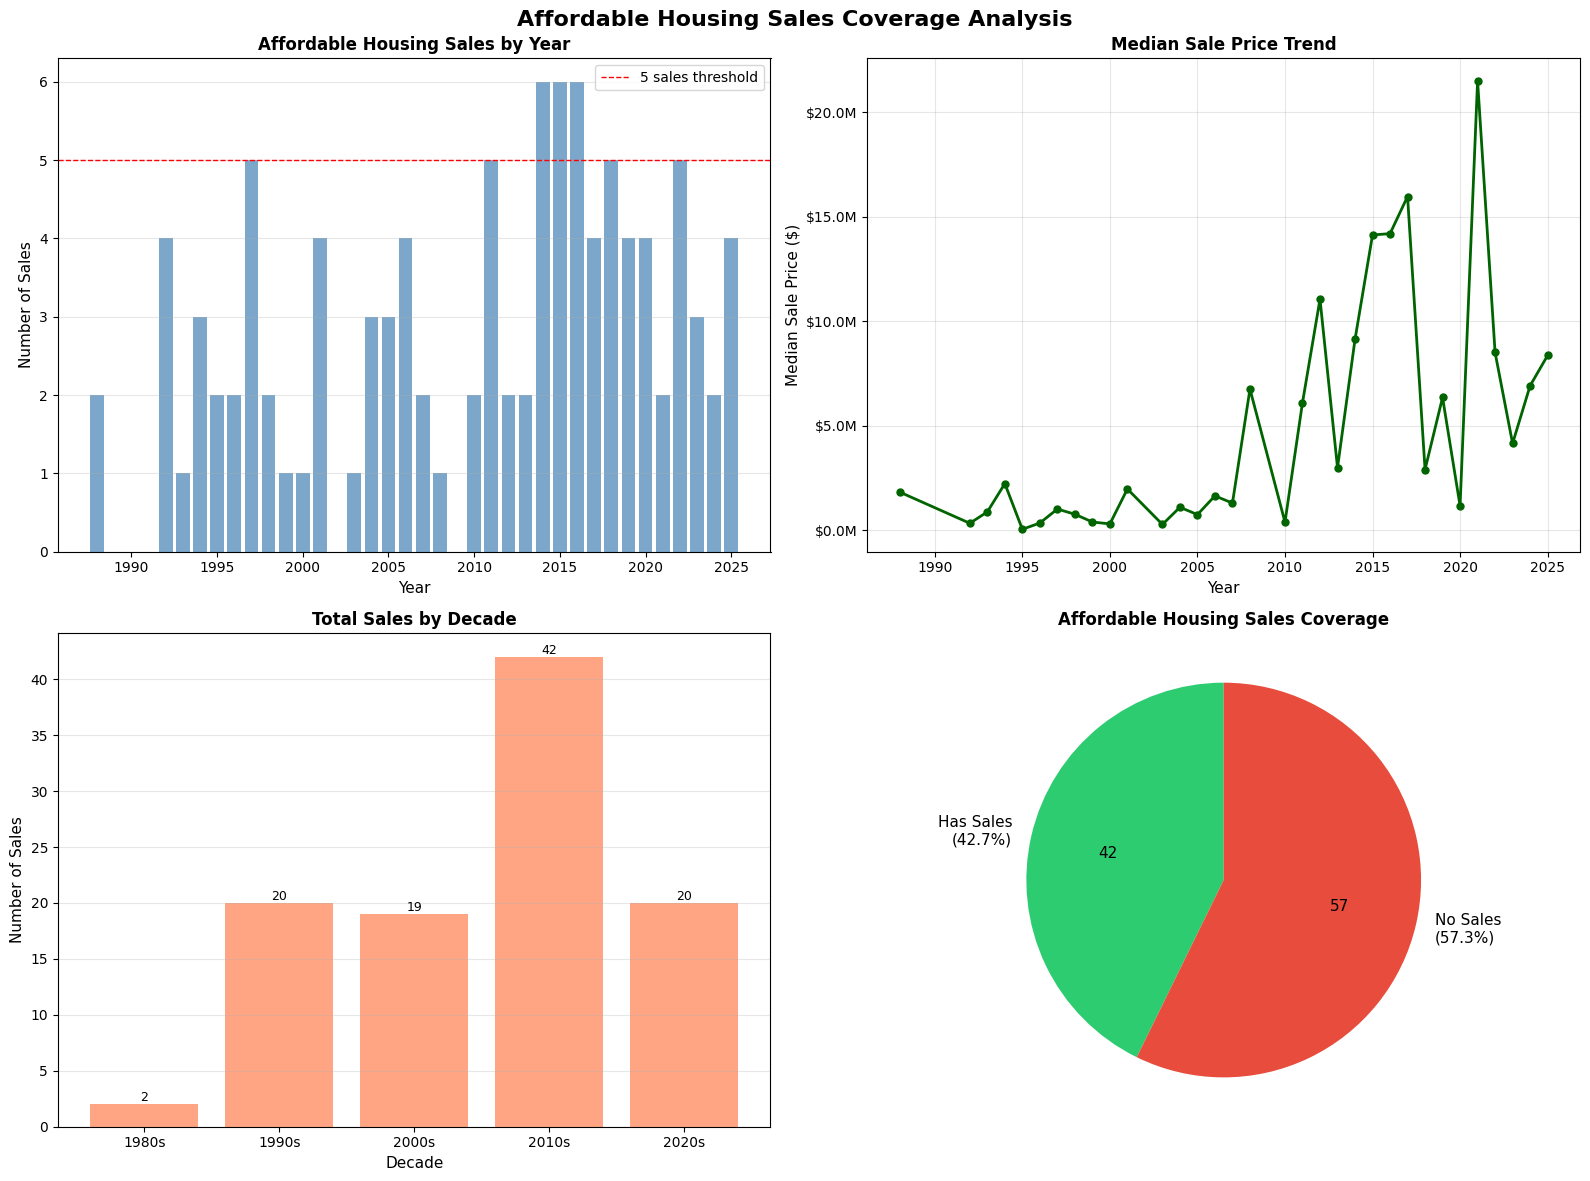


ANALYSIS COMPLETE!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# LOAD AFFORDABLE HOUSING DATA
# ============================================
print("=" * 80)
print("AFFORDABLE HOUSING SALES COVERAGE ANALYSIS BY YEAR")
print("=" * 80)

affordable_path = '/content/drive/MyDrive/San_Jose_Housing/san_jose_affordable_housing_matched.csv'
df_affordable = pd.read_csv(affordable_path)

print(f"\n✓ Loaded {len(df_affordable):,} affordable housing records")

# ============================================
# FILTER FOR VALID SALES
# ============================================
affordable_with_sales = df_affordable[
    (df_affordable['Last Sale Price'].notna()) &
    (df_affordable['Last Sale Price'] > 0) &
    (df_affordable['Last Sale Price'] < 50_000_000)
].copy()

print(f"\n📊 Sales Coverage:")
print(f"  Total affordable properties: {len(df_affordable):,}")
print(f"  Properties with valid sales: {len(affordable_with_sales):,}")
print(f"  Coverage rate: {len(affordable_with_sales)/len(df_affordable)*100:.2f}%")
print(f"  Properties WITHOUT sales: {len(df_affordable) - len(affordable_with_sales):,}")

# ============================================
# PARSE SALE YEARS
# ============================================
affordable_with_sales['sale_year'] = pd.to_datetime(
    affordable_with_sales['Last Sale Date'],
    errors='coerce'
).dt.year

# Filter for reasonable years
affordable_with_sales = affordable_with_sales[
    (affordable_with_sales['sale_year'] >= 1950) &
    (affordable_with_sales['sale_year'] <= 2025)
]

print(f"\n📅 Temporal Range:")
print(f"  Earliest sale: {affordable_with_sales['sale_year'].min():.0f}")
print(f"  Latest sale: {affordable_with_sales['sale_year'].max():.0f}")
print(f"  Span: {affordable_with_sales['sale_year'].max() - affordable_with_sales['sale_year'].min():.0f} years")

# ============================================
# YEARLY BREAKDOWN
# ============================================
print("\n" + "=" * 80)
print("SALES BY YEAR")
print("=" * 80)

yearly_sales = affordable_with_sales.groupby('sale_year').agg({
    'Last Sale Price': ['count', 'median', 'mean']
}).round(0)
yearly_sales.columns = ['count', 'median_price', 'mean_price']
yearly_sales = yearly_sales.reset_index()

print("\n--- Full Yearly Breakdown ---")
print(yearly_sales.to_string(index=False))

# ============================================
# DECADE ANALYSIS
# ============================================
print("\n" + "=" * 80)
print("SALES BY DECADE")
print("=" * 80)

affordable_with_sales['decade'] = (affordable_with_sales['sale_year'] // 10) * 10

decade_sales = affordable_with_sales.groupby('decade').agg({
    'Last Sale Price': ['count', 'median', 'mean']
}).round(0)
decade_sales.columns = ['count', 'median_price', 'mean_price']
decade_sales = decade_sales.reset_index()
decade_sales['decade_label'] = decade_sales['decade'].astype(int).astype(str) + 's'

print("\n--- Sales by Decade ---")
print(decade_sales[['decade_label', 'count', 'median_price', 'mean_price']].to_string(index=False))

# ============================================
# RECENT YEARS DETAIL (2015-2025)
# ============================================
print("\n" + "=" * 80)
print("RECENT YEARS DETAIL (2015-2025)")
print("=" * 80)

recent = yearly_sales[yearly_sales['sale_year'] >= 2015].copy()
if len(recent) > 0:
    print("\n--- Recent Sales (2015-2025) ---")
    print(recent.to_string(index=False))
    print(f"\nTotal sales 2015-2025: {recent['count'].sum():.0f}")
    print(f"Average per year: {recent['count'].mean():.1f}")
else:
    print("\n⚠️ No sales found in recent years (2015-2025)")

# ============================================
# IDENTIFY DATA GAPS
# ============================================
print("\n" + "=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

# Check for years with no sales
all_years = range(int(affordable_with_sales['sale_year'].min()), 2026)
years_with_sales = set(affordable_with_sales['sale_year'].astype(int))
years_without_sales = [y for y in all_years if y not in years_with_sales]

print(f"\n⚠️ Years with ZERO sales: {len(years_without_sales)}")
if len(years_without_sales) > 0 and len(years_without_sales) < 30:
    print(f"  Missing years: {sorted(years_without_sales)}")

# Identify sparse years (< 5 sales)
sparse_years = yearly_sales[yearly_sales['count'] < 5]
print(f"\n⚠️ Years with < 5 sales: {len(sparse_years)}")
if len(sparse_years) > 0:
    print(sparse_years[['sale_year', 'count']].to_string(index=False))

# Good coverage years (>= 5 sales)
good_years = yearly_sales[yearly_sales['count'] >= 5]
print(f"\n✓ Years with >= 5 sales: {len(good_years)}")
if len(good_years) > 0:
    print(f"  Year range: {good_years['sale_year'].min():.0f} - {good_years['sale_year'].max():.0f}")
    print(f"  Total sales in good years: {good_years['count'].sum():.0f}")

# ============================================
# RECOMMENDATIONS
# ============================================
print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR ML MODEL")
print("=" * 80)

total_sales = len(affordable_with_sales)
recent_sales = len(affordable_with_sales[affordable_with_sales['sale_year'] >= 2015])
old_sales = len(affordable_with_sales[affordable_with_sales['sale_year'] < 2015])

print(f"\n📊 Training Data Options:")
print(f"  Option 1 - All years: {total_sales} sales")
print(f"  Option 2 - Recent only (2015+): {recent_sales} sales")
print(f"  Option 3 - Pre-2015: {old_sales} sales")

if recent_sales < 30:
    print("\n⚠️ WARNING: Very few recent sales for affordable housing!")
    print("   Recommendation: Use ALL years for training (Option 1)")
    print("   Include 'sale_year' as a feature to capture market trends")
elif recent_sales < 50:
    print("\n⚠️ Limited recent sales")
    print("   Recommendation: Use all years but weight recent sales higher")
else:
    print("\n✓ Sufficient recent sales")
    print("   Recommendation: Focus on 2015+ for current market predictions")

print(f"\n💡 Strategy:")
if total_sales < 50:
    print("  - Use ALL affordable housing sales for training (including old)")
    print("  - Include sale_year as feature to adjust for time")
    print("  - Consider using non-affordable sales to augment training data")
    print("  - Focus on property characteristics that transcend time")
else:
    print("  - Sufficient data for year-based modeling")
    print("  - Include sale_year as feature")
    print("  - Can separate by time periods if needed")

# ============================================
# VISUALIZATIONS
# ============================================
print("\n" + "=" * 80)
print("CREATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Affordable Housing Sales Coverage Analysis', fontsize=16, fontweight='bold')

# Plot 1: Sales count by year
ax1 = axes[0, 0]
ax1.bar(yearly_sales['sale_year'], yearly_sales['count'], color='steelblue', alpha=0.7)
ax1.axhline(y=5, color='red', linestyle='--', linewidth=1, label='5 sales threshold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Number of Sales', fontsize=11)
ax1.set_title('Affordable Housing Sales by Year', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# Plot 2: Median price by year
ax2 = axes[0, 1]
ax2.plot(yearly_sales['sale_year'], yearly_sales['median_price'],
         marker='o', linewidth=2, markersize=5, color='darkgreen')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Median Sale Price ($)', fontsize=11)
ax2.set_title('Median Sale Price Trend', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Plot 3: Sales by decade
ax3 = axes[1, 0]
ax3.bar(decade_sales['decade_label'], decade_sales['count'], color='coral', alpha=0.7)
ax3.set_xlabel('Decade', fontsize=11)
ax3.set_ylabel('Number of Sales', fontsize=11)
ax3.set_title('Total Sales by Decade', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(zip(decade_sales['decade_label'], decade_sales['count'])):
    ax3.text(i, count, f'{int(count)}', ha='center', va='bottom', fontsize=9)

# Plot 4: Coverage comparison
ax4 = axes[1, 1]
coverage_data = {
    'Has Sales\n(42.7%)': len(affordable_with_sales),
    'No Sales\n(57.3%)': len(df_affordable) - len(affordable_with_sales)
}
colors = ['#2ecc71', '#e74c3c']
ax4.pie(coverage_data.values(), labels=coverage_data.keys(), autopct='%d',
        colors=colors, startangle=90, textprops={'fontsize': 11})
ax4.set_title('Affordable Housing Sales Coverage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/San_Jose_Housing/affordable_sales_coverage_by_year.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved visualization: affordable_sales_coverage_by_year.png")
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)


##### AFFORDABLE SET has very sparse coverage, so TRAINING is DONE FOR ALL HOUSING (AFF + NON_AFF) with a affordable_flag attached to distinguish

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 80)
print("SAN JOSE HOUSING: COMPLETE PRICE PREDICTION PIPELINE")
print("=" * 80)

# ============================================
# STEP 1: LOAD DATA
# ============================================
print("\n" + "=" * 80)
print("STEP 1: LOADING DATA")
print("=" * 80)

affordable = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/san_jose_affordable_housing_matched.csv')
nonaffordable = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/san_jose_nonaffordable_housing_matched.csv')

print(f"\n✓ Affordable: {len(affordable):,} properties")
print(f"✓ Non-affordable: {len(nonaffordable):,} properties")

# Mark housing type
affordable['is_affordable'] = 1
nonaffordable['is_affordable'] = 0

# Combine
df_all = pd.concat([affordable, nonaffordable], ignore_index=True)

print(f"✓ Combined dataset: {len(df_all):,} properties")

# ============================================
# OUTLIERS
# ============================================
print("\n" + "=" * 80)
print("OUTLIERS")
print("=" * 80)

valid_prices = df_all[(df_all['Last Sale Price'] > 0) & (df_all['Last Sale Price'].notna())]['Last Sale Price']
print(f"99.5th percentile: ${valid_prices.quantile(0.995):,.0f}")
print(f"99.9th percentile: ${valid_prices.quantile(0.999):,.0f}")

# Check low-value sales
low_sales = df_all[(df_all['Last Sale Price'] > 0) & (df_all['Last Sale Price'] < 100000)]
print(f"Sales < $100K: {len(low_sales)}")
print(f"\nSample low sales:")
print(low_sales[['Address', 'Last Sale Price', 'Number of Units', 'Building SqFt', 'sale_year']].head(20))

# Check distribution
valid_prices = df_all[(df_all['Last Sale Price'] > 0) & (df_all['Last Sale Price'].notna())]['Last Sale Price']
print(f"\n📊 Low-end percentiles:")
print(f"  Min: ${valid_prices.min():,.0f}")
print(f"  0.1th %ile: ${valid_prices.quantile(0.001):,.0f}")
print(f"  0.5th %ile: ${valid_prices.quantile(0.005):,.0f}")
print(f"  1st %ile: ${valid_prices.quantile(0.01):,.0f}")
print(f"  5th %ile: ${valid_prices.quantile(0.05):,.0f}")



SAN JOSE HOUSING: COMPLETE PRICE PREDICTION PIPELINE

STEP 1: LOADING DATA

✓ Affordable: 241 properties
✓ Non-affordable: 230,000 properties
✓ Combined dataset: 230,241 properties

OUTLIERS
99.5th percentile: $10,499,965
99.9th percentile: $74,227,200
Sales < $100K: 1851

Sample low sales:
                                                Address  Last Sale Price  \
21    1380 Blossom Hill Rd Unit 110, San Jose, CA, 9...          40000.0   
171                  28 Bassett St, San Jose, CA, 95110          43000.0   
267                   474 N 3rd St, San Jose, CA, 95112          66000.0   
373                232 E Empire St, San Jose, CA, 95112          90000.0   
388              221 Washington St, San Jose, CA, 95112          73000.0   
584                  479 N 10th St, San Jose, CA, 95112          42000.0   
615                  429 N 11th St, San Jose, CA, 95112          40000.0   
618                  411 N 11th St, San Jose, CA, 95112          95000.0   
640                401 E

In [ ]:
!pip install xgboost

import xgboost as xgb
print(xgb.get_config())

'''
    import xgboost as xgb

    # Example for a classifier
    model = xgb.XGBClassifier(tree_method='gpu_hist', device='cuda', ...)

    # Example for a regressor
    model = xgb.XGBRegressor(tree_method='gpu_hist', device='cuda', ...)
'''

{'use_rmm': False, 'verbosity': 1}


"\n    import xgboost as xgb\n\n    # Example for a classifier\n    model = xgb.XGBClassifier(tree_method='gpu_hist', device='cuda', ...)\n\n    # Example for a regressor\n    model = xgb.XGBRegressor(tree_method='gpu_hist', device='cuda', ...)\n"

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 80)
print("SAN JOSE HOUSING: COMPLETE PRICE PREDICTION PIPELINE (XGBoost - GPU)")
print("=" * 80)

# ============================================
# STEP 1: LOAD DATA
# ============================================
print("\n" + "=" * 80)
print("STEP 1: LOADING DATA")
print("=" * 80)

affordable = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/san_jose_affordable_housing_matched.csv')
nonaffordable = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/san_jose_nonaffordable_housing_matched.csv')

print(f"\n✓ Affordable: {len(affordable):,} properties")
print(f"✓ Non-affordable: {len(nonaffordable):,} properties")

affordable['is_affordable'] = 1
nonaffordable['is_affordable'] = 0
df_all = pd.concat([affordable, nonaffordable], ignore_index=True)

print(f"✓ Combined dataset: {len(df_all):,} properties")

# ============================================
# STEP 2: CLEAN DATA
# ============================================
print("\n" + "=" * 80)
print("STEP 2: CLEANING DATA")
print("=" * 80)

columns_to_remove = [
    'Lot Area SqFt', 'Lot Area Acres', 'Land Size Acres',
    'affordable_rental_flag', 'affordable_rental_mf_flag', 'affordable_rental_sf_flag',
    'affordable_rental_sro_flag', 'mobile_home_flag', 'poolhouse_flag', 'escalator_flag',
    'affordable_match_method', 'affordable_match_distance', 'match_type',
    'address_norm', 'parcel_clean'
]

removed_count = 0
for col in columns_to_remove:
    if col in df_all.columns:
        df_all = df_all.drop(columns=[col])
        removed_count += 1

print(f"\n✓ Removed {removed_count} unnecessary columns")
print(f"✓ Remaining columns: {len(df_all.columns)}")

# ============================================
# STEP 3: PREPARE TRAINING DATA
# ============================================
print("\n" + "=" * 80)
print("STEP 3: PREPARING TRAINING DATA")
print("=" * 80)

target = 'Last Sale Price'

# Calculate floor and ceiling
valid_prices = df_all[(df_all[target] > 0) & (df_all[target].notna())][target]
price_floor = 10000
price_ceiling = valid_prices.quantile(0.999)

print(f"\n📊 Price Distribution:")
print(f"  Min: ${valid_prices.min():,.0f}")
print(f"  0.1th %ile: ${valid_prices.quantile(0.001):,.0f}")
print(f"  1st %ile: ${valid_prices.quantile(0.01):,.0f}")
print(f"  Median: ${valid_prices.median():,.0f}")
print(f"  99.9th %ile: ${price_ceiling:,.0f}")
print(f"  Max: ${valid_prices.max():,.0f}")
print(f"\n✓ Using price range: ${price_floor:,} - ${price_ceiling:,.0f}")

# Filter
train_data = df_all[
    (df_all[target].notna()) &
    (df_all[target] >= price_floor) &
    (df_all[target] <= price_ceiling) &
    (df_all['sale_year'] >= 1990) &
    (df_all['sale_year'] <= 2025)
].copy()

print(f"\n✓ Training sales: {len(train_data):,}")
print(f"  Excluded < $10K: {len(df_all[(df_all[target] > 0) & (df_all[target] < price_floor)]):,}")
print(f"  Excluded > ${price_ceiling:,.0f}: {len(df_all[df_all[target] > price_ceiling]):,}")

# Feature engineering
train_data['property_age'] = 2025 - train_data['Year Built']
train_data['log_price'] = np.log1p(train_data[target])

# Define features
features = [
    'Building SqFt',
    'Number of Units',
    'Bedrooms',
    'Bathrooms',
    'Year Built',
    'property_age',
    'Building Stories',
    'Latitude',
    'Longitude',
    'Total Assessed Value',
    'Assessed Land Value',
    'Assessed Improvement Value',
    'sale_year',
    'is_affordable'
]

available_features = [f for f in features if f in train_data.columns]
print(f"\n✓ Features available: {len(available_features)}")

# Prepare X and y
feature_medians = train_data[available_features].median()
X = train_data[available_features].fillna(feature_medians)
y_log = train_data['log_price']

# ============================================
# STEP 4: TRAIN XGBOOST MODEL (WITH GPU)
# ============================================
print("\n" + "=" * 80)
print("STEP 4: TRAINING XGBOOST REGRESSOR (GPU)")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"\n✓ Train set: {len(X_train):,} samples")
print(f"✓ Test set: {len(X_test):,} samples")

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device='cuda',
    predictor="gpu_predictor",
    random_state=42,
    verbosity=1,
    reg_alpha=1.0, # L1 regularization
    reg_lambda=2.0, # L2 regularization
    min_child_weight=5,
    early_stopping_rounds=10
)

print(f"\n⚡ Training XGBoost (watch GPU utilization in Colab sidebar)...")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)

print(f"✓ Model trained with {model.n_estimators} boosting rounds")

# ============================================
# STEP 5: EVALUATE MODEL
# ============================================
print("\n" + "=" * 80)
print("STEP 5: MODEL VALIDATION")
print("=" * 80)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)
y_train_pred_price = np.expm1(y_train_pred)
y_test_pred_price = np.expm1(y_test_pred)

train_r2 = r2_score(y_train_actual, y_train_pred_price)
test_r2 = r2_score(y_test_actual, y_test_pred_price)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_price)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_price))
test_mape = np.mean(np.abs((y_test_actual - y_test_pred_price) / y_test_actual)) * 100

print(f"\n📊 MODEL PERFORMANCE:")
print(f"  Training R²:  {train_r2:.4f}")
print(f"  Test R²:      {test_r2:.4f}")
print(f"  Test MAE:     ${test_mae:,.0f}")
print(f"  Test RMSE:    ${test_rmse:,.0f}")
print(f"  Test MAPE:    {test_mape:.2f}%")
print(f"  Overfitting:  {train_r2 - test_r2:.4f}")

if test_r2 >= 0.65:
    print(f"\n  ✅ EXCELLENT! R² = {test_r2:.3f}")
elif test_r2 >= 0.5:
    print(f"\n  ✅ GOOD! R² = {test_r2:.3f}")


SAN JOSE HOUSING: COMPLETE PRICE PREDICTION PIPELINE (XGBoost - GPU)

STEP 1: LOADING DATA

✓ Affordable: 241 properties
✓ Non-affordable: 230,000 properties
✓ Combined dataset: 230,241 properties

STEP 2: CLEANING DATA

✓ Removed 12 unnecessary columns
✓ Remaining columns: 42

STEP 3: PREPARING TRAINING DATA

📊 Price Distribution:
  Min: $100
  0.1th %ile: $10,000
  1st %ile: $94,000
  Median: $640,000
  99.9th %ile: $74,227,200
  Max: $886,600,000

✓ Using price range: $10,000 - $74,227,200

✓ Training sales: 160,321
  Excluded < $10K: 148
  Excluded > $74,227,200: 166

✓ Features available: 14

STEP 4: TRAINING XGBOOST REGRESSOR (GPU)

✓ Train set: 128,256 samples
✓ Test set: 32,065 samples

⚡ Training XGBoost (watch GPU utilization in Colab sidebar)...
[0]	validation_0-rmse:0.72404
[1]	validation_0-rmse:0.67481


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:160: UserWarning: [22:24:16] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "predictor" } are not used.

  warnings.warn(smsg, UserWarning)


[2]	validation_0-rmse:0.62277
[3]	validation_0-rmse:0.57641
[4]	validation_0-rmse:0.54336
[5]	validation_0-rmse:0.51511
[6]	validation_0-rmse:0.48238
[7]	validation_0-rmse:0.45370
[8]	validation_0-rmse:0.42886
[9]	validation_0-rmse:0.40743
[10]	validation_0-rmse:0.38901
[11]	validation_0-rmse:0.37748
[12]	validation_0-rmse:0.36343
[13]	validation_0-rmse:0.35131
[14]	validation_0-rmse:0.34106
[15]	validation_0-rmse:0.33254
[16]	validation_0-rmse:0.32734
[17]	validation_0-rmse:0.32076
[18]	validation_0-rmse:0.31537
[19]	validation_0-rmse:0.31063
[20]	validation_0-rmse:0.30676
[21]	validation_0-rmse:0.30345
[22]	validation_0-rmse:0.30044
[23]	validation_0-rmse:0.29798
[24]	validation_0-rmse:0.29596
[25]	validation_0-rmse:0.29420
[26]	validation_0-rmse:0.29314
[27]	validation_0-rmse:0.29166
[28]	validation_0-rmse:0.29052
[29]	validation_0-rmse:0.28958
[30]	validation_0-rmse:0.28869
[31]	validation_0-rmse:0.28805
[32]	validation_0-rmse:0.28737
[33]	validation_0-rmse:0.28659
[34]	validation_

### Prediction

In [ ]:
errors_pct = np.abs((y_test_actual - y_test_pred_price) / y_test_actual) * 100
print(f"\n📊 Prediction Accuracy:")
print(f"  Within 10%: {(errors_pct <= 10).sum():,}/{len(errors_pct):,} ({(errors_pct <= 10).sum()/len(errors_pct)*100:.1f}%)")
print(f"  Within 20%: {(errors_pct <= 20).sum():,}/{len(errors_pct):,} ({(errors_pct <= 20).sum()/len(errors_pct)*100:.1f}%)")
print(f"  Within 30%: {(errors_pct <= 30).sum():,}/{len(errors_pct):,} ({(errors_pct <= 30).sum()/len(errors_pct)*100:.1f}%)")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\n📊 Top 10 Features:")
print(importance_df.head(10).to_string(index=False))

# ============================================
# STEP 6: GENERATE PREDICTIONS
# ============================================
print("\n" + "=" * 80)
print("STEP 6: GENERATING PREDICTIONS (2015, 2017, 2019, 2021, 2023, 2025)")
print("=" * 80)

no_sales = df_all[df_all[target].isna()].copy()

print(f"\n✓ Properties without sales: {len(no_sales):,}")
print(f"  - Affordable: {(no_sales['is_affordable'] == 1).sum():,}")
print(f"  - Non-affordable: {(no_sales['is_affordable'] == 0).sum():,}")

prediction_years = [2015, 2017, 2019, 2021, 2023, 2025]

print(f"\n✓ Prediction years: {prediction_years}")
print(f"\n🔮 Generating predictions... (GPU batch)")

predictions_list = []
batch_size = 10000

for batch_num, batch_start in enumerate(range(0, len(no_sales), batch_size)):
    batch_end = min(batch_start + batch_size, len(no_sales))
    batch = no_sales.iloc[batch_start:batch_end]

    print(f"  Batch {batch_num+1}/{(len(no_sales)-1)//batch_size+1}: {batch_start:,}-{batch_end:,}")

    for idx, row in batch.iterrows():
        year_built = row.get('Year Built', 2000)
        years_list = []
        prices_list = []
        pred_dict = {}

        for year in prediction_years:
            if year >= year_built:
                property_features = {}
                for feat in available_features:
                    if feat == 'sale_year':
                        property_features[feat] = year
                    elif feat == 'property_age':
                        property_features[feat] = year - year_built
                    else:
                        property_features[feat] = row.get(feat, np.nan)
                X_predict = pd.DataFrame([property_features]).fillna(feature_medians)
                pred_log = model.predict(X_predict)[0] # Get the scalar!
                predicted_price = int(round(np.expm1(pred_log), 0))
                years_list.append(year)
                prices_list.append(predicted_price)
                pred_dict[f'predicted_price_{year}'] = predicted_price

        predictions_list.append({
            'Parcel ID': row.get('Parcel ID'),
            'Address': row.get('Address'),
            'is_affordable': row.get('is_affordable'),
            # Predictions (individual years)
            'predicted_price_2015': pred_dict.get('predicted_price_2015', np.nan),
            'predicted_price_2017': pred_dict.get('predicted_price_2017', np.nan),
            'predicted_price_2019': pred_dict.get('predicted_price_2019', np.nan),
            'predicted_price_2021': pred_dict.get('predicted_price_2021', np.nan),
            'predicted_price_2023': pred_dict.get('predicted_price_2023', np.nan),
            'predicted_price_2025': pred_dict.get('predicted_price_2025', np.nan),
            'prediction_years': years_list,
            'predicted_prices': prices_list
        })

df_predictions = pd.DataFrame(predictions_list)
print(f"\n✓ Complete: {len(df_predictions):,} properties")

# ============================================
# STEP 7: SPLIT & SAVE
# ============================================
print("\n" + "=" * 80)
print("STEP 7: SPLITTING & SAVING")
print("=" * 80)

df_affordable_pred = df_predictions[df_predictions['is_affordable'] == 1].copy()
df_nonaffordable_pred = df_predictions[df_predictions['is_affordable'] == 0].copy()

print(f"\n✓ Affordable: {len(df_affordable_pred):,}")
print(f"✓ Non-affordable: {len(df_nonaffordable_pred):,}")

affordable_out = '/content/drive/MyDrive/San_Jose_Housing/affordable_housing_predicted_sales.csv'
nonaffordable_out = '/content/drive/MyDrive/San_Jose_Housing/nonaffordable_housing_predicted_sales.csv'

df_affordable_pred.to_csv(affordable_out, index=False)
df_nonaffordable_pred.to_csv(nonaffordable_out, index=False)

print(f"\n✓ Saved: {affordable_out}")
print(f"✓ Saved: {nonaffordable_out}")

print(f"\n📊 2025 Predictions:")
print(f"  Affordable median: ${df_affordable_pred['predicted_price_2025'].median():,.0f}")
print(f"  Non-affordable median: ${df_nonaffordable_pred['predicted_price_2025'].median():,.0f}")

print("\n" + "=" * 80)
print("✅ COMPLETE!")
print("=" * 80)
print(f"\n🎯 Model: R² = {test_r2:.3f}, MAE = ${test_mae:,.0f}")
print(f"📦 Predictions: {len(df_predictions):,} properties")
print(f"📅 Years: {prediction_years}")



📊 Prediction Accuracy:
  Within 10%: 24,168/32,065 (75.4%)
  Within 20%: 28,284/32,065 (88.2%)
  Within 30%: 29,672/32,065 (92.5%)

📊 Top 10 Features:
                   Feature  Importance
      Total Assessed Value    0.408833
                 sale_year    0.224495
Assessed Improvement Value    0.098696
             is_affordable    0.074560
           Number of Units    0.048576
              property_age    0.024367
       Assessed Land Value    0.023819
             Building SqFt    0.020285
                  Bedrooms    0.015393
          Building Stories    0.014727

STEP 6: GENERATING PREDICTIONS (2015, 2017, 2019, 2021, 2023, 2025)

✓ Properties without sales: 64,962
  - Affordable: 130
  - Non-affordable: 64,832

✓ Prediction years: [2015, 2017, 2019, 2021, 2023, 2025]

🔮 Generating predictions... (GPU batch)
  Batch 1/7: 0-10,000


In [ ]:
import pandas as pd

# Load your matched CSVs
affordable_matched = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/san_jose_affordable_housing_matched.csv')
nonaffordable_matched = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/san_jose_nonaffordable_housing_matched.csv')

# Load your prediction files
affordable_preds = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/affordable_housing_predicted_sales.csv')
nonaffordable_preds = pd.read_csv('/content/drive/MyDrive/San_Jose_Housing/nonaffordable_housing_predicted_sales.csv')

# Define columns to keep
columns_to_keep = [
    'Parcel ID',
    'Address',
    'Current Use',
    'Latitude',
    'Longitude',
    'Last Sale Date',
    'Last Sale Price',
    'predicted_prices',
    'Number of Buildings',
    'Building Stories',
    'Number of Units',
    'Total Assessed Value',
    'Assessed Land Value',
    'Year Built',
    'Bedrooms',
    'Bathrooms',
    'Parking Garage Area',
    'Building SqFt',
    'Land Size Acres'
]

# Process affordable
affordable_no_sales = affordable_matched[affordable_matched['Last Sale Price'].isna()]
affordable_with_sales = affordable_matched[affordable_matched['Last Sale Price'].notna()]

affordable_no_sales = affordable_no_sales.merge(affordable_preds, on=['Parcel ID', 'Address'], how='left')
affordable_final = pd.concat([affordable_with_sales, affordable_no_sales], ignore_index=True)

# Process non-affordable
# Deduplicate master files using Parcel ID, Address, Latitude, and Longitude
nonaffordable_matched = nonaffordable_matched.drop_duplicates(subset=['Parcel ID', 'Address', 'Latitude', 'Longitude'])


# Deduplicate prediction files using Parcel ID and Address
nonaffordable_preds = nonaffordable_preds.drop_duplicates(subset=['Parcel ID', 'Address'])

# Ensure data types match
nonaffordable_matched['Parcel ID'] = nonaffordable_matched['Parcel ID'].astype(str).str.strip()
nonaffordable_preds['Parcel ID'] = nonaffordable_preds['Parcel ID'].astype(str).str.strip()

# Split non-affordable into valid sales and no sales
nonaffordable_with_sales = nonaffordable_matched[
    (nonaffordable_matched['Last Sale Price'].notna()) &
    (nonaffordable_matched['Last Sale Price'] > 0)
]

nonaffordable_no_sales = nonaffordable_matched[
    (nonaffordable_matched['Last Sale Price'].isna()) |
    (nonaffordable_matched['Last Sale Price'] <= 0)
]


# Merge predictions for no sales
nonaffordable_no_sales = nonaffordable_no_sales.merge(nonaffordable_preds, on=['Parcel ID', 'Address'], how='left')

# Combine valid sales and predictions
nonaffordable_final = pd.concat([nonaffordable_with_sales, nonaffordable_no_sales], ignore_index=True)

print(f"✓ nonaffordable_with_sales: {len(nonaffordable_with_sales):,} records")
print(f"✓ nonaffordable_no_sales: {len(nonaffordable_no_sales):,} records")
print(f"✓ nonaffordable_final: {len(nonaffordable_final):,} records")



# Keep only specified columns
affordable_final = affordable_final[[col for col in columns_to_keep if col in affordable_final.columns]]
nonaffordable_final = nonaffordable_final[[col for col in columns_to_keep if col in nonaffordable_final.columns]]

# Define multi-family categories
multi_family_categories = [
    'Condominium or Townhouse',
    'Five or more Family',
    'Fraternity, Sorority, Boarding, Rooming House',
    'Three and Four Family',
    'Two Family',
    'Farm Labor Camp in Urban Location'
]

# Split by property type
for df, name in [(affordable_final, 'affordable'), (nonaffordable_final, 'nonaffordable')]:
    sf = df[df['Current Use'] == 'Single Family']
    mf = df[df['Current Use'].isin(multi_family_categories)]

    sf.to_csv(f'/content/drive/MyDrive/San_Jose_Housing/{name}_single_family.csv', index=False)
    mf.to_csv(f'/content/drive/MyDrive/San_Jose_Housing/{name}_multi_family.csv', index=False)

    print(f"✓ {name}_single_family: {len(sf):,} records")
    print(f"✓ {name}_multi_family: {len(mf):,} records")
    print(f"✓ {name}_total: {len(sf) + len(mf):,} records")

print("✓ All files saved!")



✓ nonaffordable_with_sales: 163,568 records
✓ nonaffordable_no_sales: 63,997 records
✓ nonaffordable_final: 227,565 records
✓ affordable_single_family: 24 records
✓ affordable_multi_family: 196 records
✓ affordable_total: 220 records
✓ nonaffordable_single_family: 171,280 records
✓ nonaffordable_multi_family: 47,964 records
✓ nonaffordable_total: 219,244 records
✓ All files saved!
